In [13]:
# Importación de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
pd.set_option("display.max_columns", None)

In [15]:
df_unido = pd.read_csv("files/unido.csv", index_col=0)
df_unido.head()

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,status_client,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,1,0,0,0,0,0.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,2,3,0,3,2823,282.0,0,0
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,3,0,0,0,0,0.0,0,0
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,4,0,0,0,0,0.0,0,0
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2018,10,6,2,8,3352,335.0,465,38


## Fase 3: Visualizacion

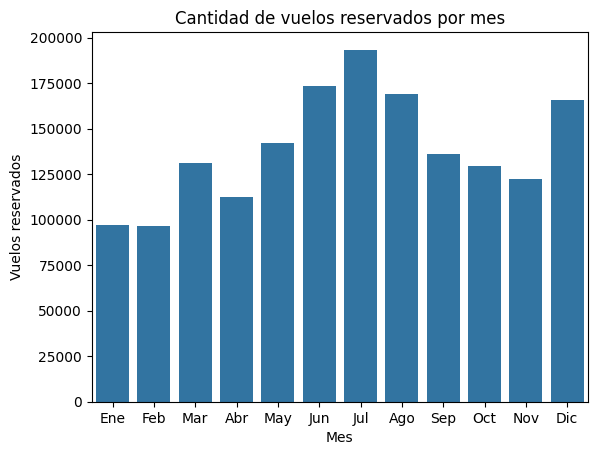

In [20]:
# 1. ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
vuelos_mes = df_unido.groupby("month")["flights_booked"].sum().reset_index()

sns.barplot(data=vuelos_mes, x="month", y="flights_booked")

plt.title("Cantidad de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Vuelos reservados")
plt.xticks(range(0, 12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()

El gráfico muestra una clara **estacionalidad en la demanda de vuelos**. Durante los primeros meses del año (enero–abril) el volumen se mantiene relativamente bajo y estable, pero a partir de mayo comienza a crecer de forma sostenida, alcanzando su **pico en julio**, lo que sugiere un fuerte efecto de la temporada de verano y vacaciones.

Después de este máximo, se observa una **caída progresiva entre agosto y noviembre**, probablemente asociada al fin del periodo vacacional. Finalmente, en diciembre hay un **repunte importante**, que podría explicarse por los viajes de fin de año.

En resumen, la demanda está muy influenciada por periodos vacacionales, lo que indica oportunidades claras para ajustar precios, capacidad o campañas comerciales según la época del año.


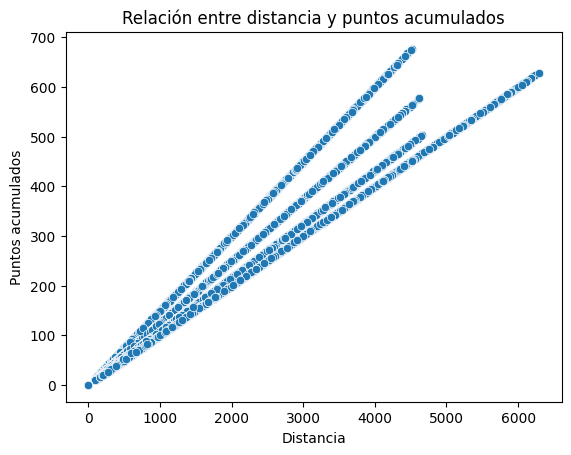

In [23]:
# 2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes?
sns.scatterplot(data=df_unido, x="distance", y="points_accumulated")

plt.title("Relación entre distancia y puntos acumulados")
plt.xlabel("Distancia")
plt.ylabel("Puntos acumulados")
plt.show()

El gráfico muestra una relación claramente positiva entre la distancia recorrida y los puntos acumulados: a mayor distancia, mayor cantidad de puntos obtenidos. Esto es consistente con un esquema de fidelización basado en kilómetros o millas.

Además, se observan varias “líneas” o agrupaciones, lo que sugiere que no todos los clientes acumulan puntos al mismo ritmo. Esto podría deberse a distintos niveles de membresía, promociones o tipos de tarifa, donde algunos perfiles reciben más puntos por la misma distancia.

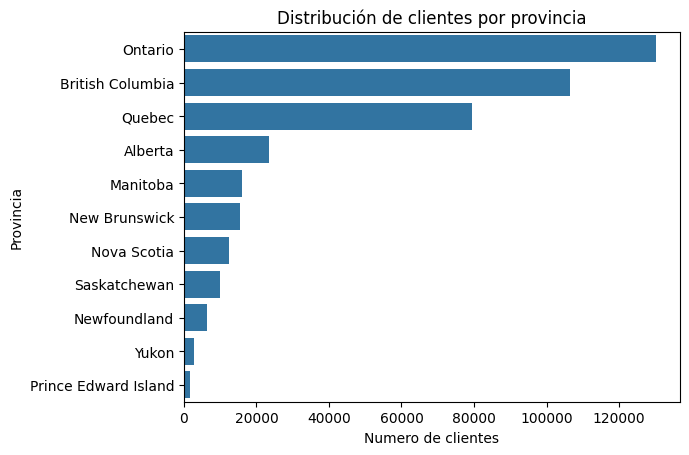

In [27]:
# 3. ¿Cuál es la distribución de los clientes por provincia o estado?
clientes_provincia = df_unido["province"].value_counts().reset_index()
clientes_provincia.columns = ["province", "clientes"]

sns.barplot(data=clientes_provincia, x="clientes", y="province")

plt.title("Distribución de clientes por provincia")
plt.xlabel("Numero de clientes")
plt.ylabel("Provincia")

plt.show()

El gráfico muestra una alta concentración de clientes en pocas provincias. Ontario lidera claramente con la mayor base de clientes, seguido por British Columbia y Quebec, que también tienen volúmenes significativamente altos. Esto indica que el negocio tiene su mayor penetración en las regiones más pobladas del país.

A partir de ahí, se observa una caída marcada en el resto de provincias, donde Alberta aún mantiene un nivel relevante, pero las demás presentan volúmenes considerablemente menores.

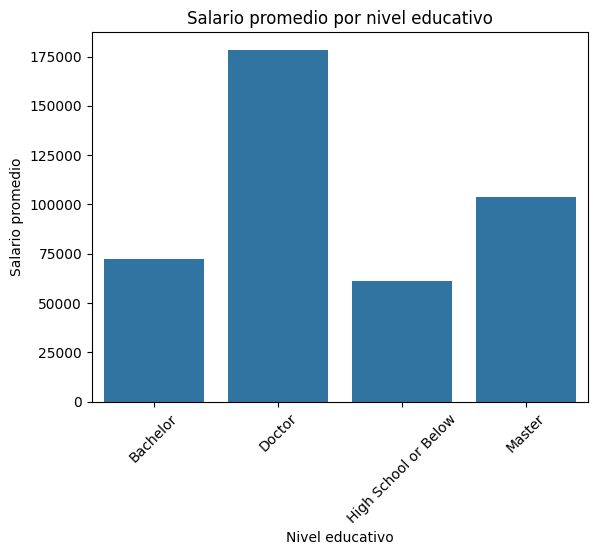

In [ ]:
# 4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
df_filtrado = df_unido[df_unido['education'] != 'College'] #aqui le digo que ignore College

salario_educacion = df_filtrado.groupby("education")["salary"].mean().reset_index()

sns.barplot(data=salario_educacion, x="education", y="salary")

plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra una relación clara entre el nivel educativo y el salario promedio. A medida que aumenta el nivel de estudios, los ingresos tienden a ser mayores.

En particular, las personas con Doctorado destacan significativamente, con el salario promedio más alto, muy por encima del resto. En segundo lugar se encuentran quienes tienen Maestría, lo que refuerza la idea de que la especialización avanzada tiene un impacto importante en los ingresos.

Por otro lado, los niveles de Bachelor (licenciatura) y especialmente High School or Below presentan salarios considerablemente más bajos, siendo este último el grupo con menor ingreso promedio.

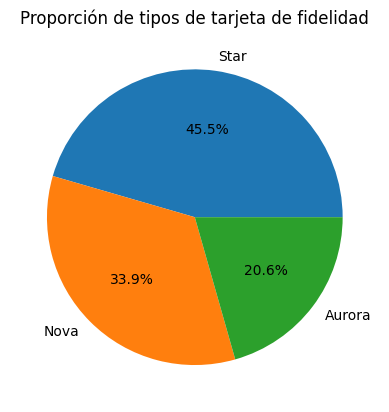

In [31]:
# 5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
tarjetas = df_unido["loyalty_card"].value_counts().reset_index()
tarjetas.columns = ["loyalty_card", "clientes"]

plt.pie(tarjetas["clientes"], labels=tarjetas["loyalty_card"], autopct="%1.1f%%")

plt.title("Proporción de tipos de tarjeta de fidelidad")
plt.show()

El gráfico muestra una distribución desigual en los tipos de tarjeta de fidelidad, donde una categoría domina claramente.

La tarjeta Star concentra la mayor proporción (45.5%), lo que indica que casi la mitad de los clientes pertenece a este segmento. Le sigue Nova (33.9%), con una presencia también relevante, mientras que Aurora (20.6%) queda bastante por detrás.

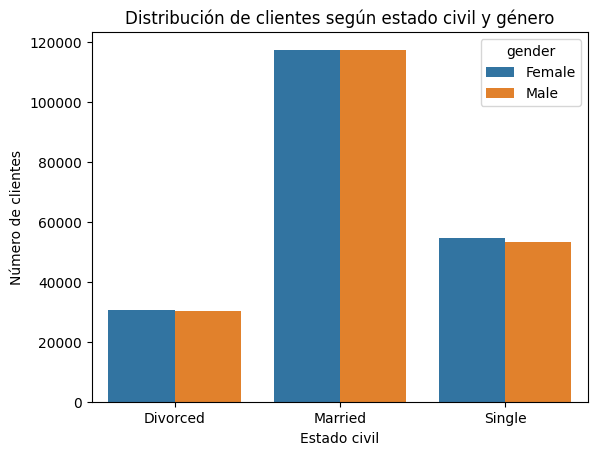

In [32]:
# 6. ¿Cómo se distribuyen los clientes según su estado civil y género?
estado_genero = df_unido.groupby(["marital_status", "gender"]).size().reset_index(name="clientes")

sns.barplot(data=estado_genero, x="marital_status", y="clientes", hue="gender")

plt.title("Distribución de clientes según estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")
plt.show()

El gráfico muestra que la distribución de clientes por estado civil está fuertemente concentrada en personas casadas, muy por encima de los otros grupos. Este segmento representa, con diferencia, la mayor parte de la base de clientes.

En segundo lugar aparecen los clientes solteros, con un volumen moderado, mientras que los divorciados constituyen el grupo más pequeño.

Un punto interesante es que no se observan diferencias relevantes entre hombres y mujeres en ninguno de los estados civiles: las barras son prácticamente iguales en cada categoría. Esto indica que el género no está influyendo significativamente en esta distribución.